In [19]:
import pandas as pd

# Read the data
#cancerData = pd.read_csv("Cancer_Data.csv")
cancerData = pd.read_csv("/kaggle/input/breast-cancer-data/Cancer_Data.csv")
cancerData.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.5, 0, 'Data points')

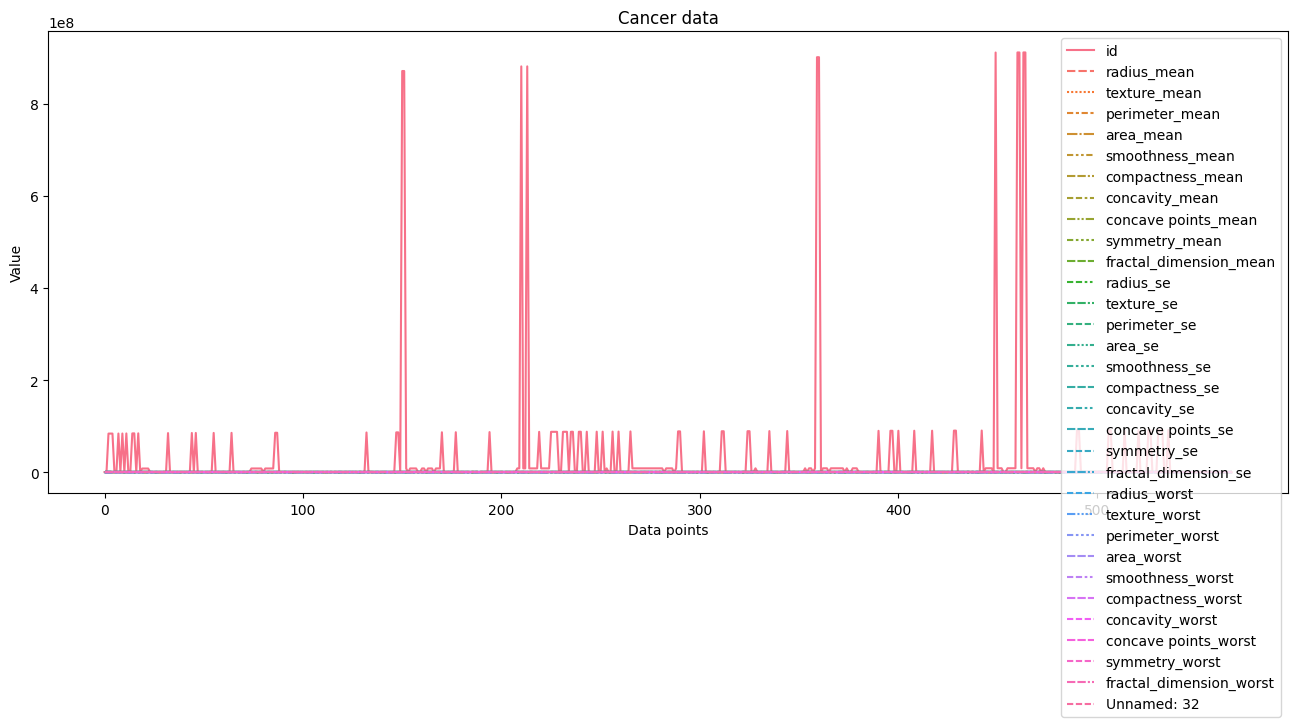

In [20]:
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Set the width and height of the figure
plt.figure(figsize=(16,6))

# Add title
plt.title("Cancer data")

# Line chart showing how FIFA rankings evolved over time
sns.lineplot(data=cancerData)

# Add label for horizontal axis
plt.ylabel("Value")
plt.xlabel("Data points")

In [21]:
cancerData['diagnosis'] = cancerData['diagnosis'].map({"M":1, "B":0})

In [22]:
# Separate target from predictors
y = cancerData.diagnosis
X = cancerData.copy()
#X.drop(['diagnosis'], axis=1, inplace=True)
X.drop(['diagnosis', 'id', 'concavity_se', 'fractal_dimension_se', 'smoothness_se', 'texture_se','Unnamed: 32'], axis=1, inplace=True)

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.5, 0, 'Data points')

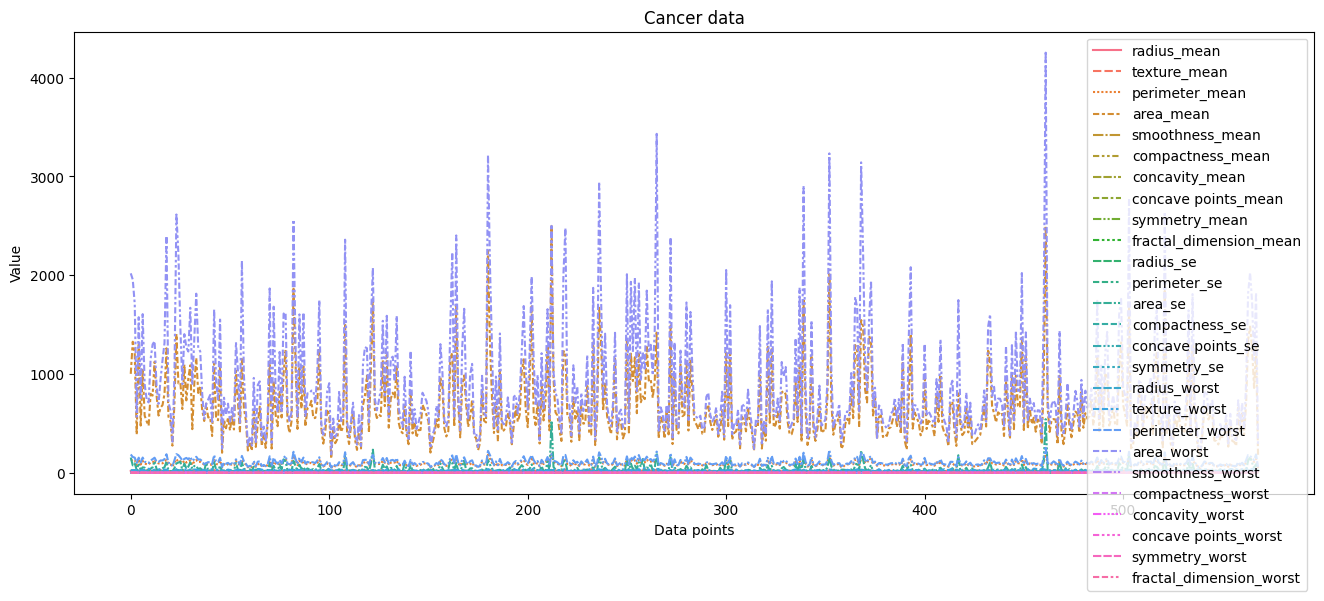

In [23]:
# Set the width and height of the figure
plt.figure(figsize=(16,6))

# Add title
plt.title("Cancer data")

# Line chart showing how FIFA rankings evolved over time
sns.lineplot(data=X)

# Add label for horizontal axis
plt.ylabel("Value")
plt.xlabel("Data points")

In [24]:
# Break off validation set from training data

from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size= 0.8, test_size= 0.2, random_state=0)

In [25]:
X_train.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
338,10.05,17.53,64.41,310.8,0.10070,0.07326,0.02511,0.01775,0.1890,0.06331,...,11.16,26.84,71.98,384.0,0.1402,0.14020,0.1055,0.06499,0.2894,0.07664
427,10.80,21.98,68.79,359.9,0.08801,0.05743,0.03614,0.01404,0.2016,0.05977,...,12.76,32.04,83.69,489.5,0.1303,0.16960,0.1927,0.07485,0.2965,0.07662
406,16.14,14.86,104.30,800.0,0.09495,0.08501,0.05500,0.04528,0.1735,0.05875,...,17.71,19.58,115.90,947.9,0.1206,0.17220,0.2310,0.11290,0.2778,0.07012
96,12.18,17.84,77.79,451.1,0.10450,0.07057,0.02490,0.02941,0.1900,0.06635,...,12.83,20.92,82.14,495.2,0.1140,0.09358,0.0498,0.05882,0.2227,0.07376
490,12.25,22.44,78.18,466.5,0.08192,0.05200,0.01714,0.01261,0.1544,0.05976,...,14.17,31.99,92.74,622.9,0.1256,0.18040,0.1230,0.06335,0.3100,0.08203


In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error

In [27]:
# Preprocessing for numerical data
numerical_transformer = SimpleImputer(strategy='constant')

In [28]:
from xgboost import XGBClassifier

# Define model
model_1 = XGBClassifier(random_state=0)

In [29]:
# Bundle preprocessing and modeling code in a pipeline
Pipeline_1 = Pipeline(steps=[('preprocessor', numerical_transformer),
                      ('model', model_1)
                     ])


In [30]:
# Preprocessing of training data, fit model 
Pipeline_1.fit(X_train, y_train)

Pipeline(steps=[('preprocessor', SimpleImputer(strategy='constant')),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, random_state=0, ...))])

In [31]:
# Preprocessing of validation data, get predictions
preds = Pipeline_1.predict(X_valid)

In [32]:
print('MAE:', mean_absolute_error(y_valid, preds))

MAE: 0.02631578947368421


In [33]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [34]:
print("Accuracy:", accuracy_score(y_valid, preds))
print("Confusion Matrix:\n", confusion_matrix(y_valid, preds))
print("Classification Report:\n", classification_report(y_valid, preds))

Accuracy: 0.9736842105263158
Confusion Matrix:
 [[65  2]
 [ 1 46]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.97      0.98        67
           1       0.96      0.98      0.97        47

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [35]:
# Define the model
my_model_2 = XGBClassifier(n_estimators=1000, learning_rate=0.05) 

# Fit the model
my_model_2.fit(X_train, y_train, 
             early_stopping_rounds=5, 
             eval_set=[(X_valid, y_valid)], 
             verbose=False)

# Get predictions
predictions_2 = my_model_2.predict(X_valid)

# Calculate MAE
mae_2 = mean_absolute_error(predictions_2,y_valid)

# print MAE
print("Mean Absolute Error:" , mae_2)
print("Accuracy:", accuracy_score(y_valid, preds))
print("Confusion Matrix:\n", confusion_matrix(y_valid, preds))
print("Classification Report:\n", classification_report(y_valid, preds))


/usr/local/lib/python3.11/dist-packages/xgboost/sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


Mean Absolute Error: 0.03508771929824561
Accuracy: 0.9736842105263158
Confusion Matrix:
 [[65  2]
 [ 1 46]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.97      0.98        67
           1       0.96      0.98      0.97        47

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [36]:
# Define the model 
my_model_2 = XGBClassifier(n_estimators=1000, learning_rate=0.05) # Your code here 
Pipeline_2 = Pipeline(steps=[('preprocessor', numerical_transformer), 
                             ('model', my_model_2) ]) 
# Fit the model 
# Preprocessing of training data, fit model 
Pipeline_2.fit(X_train, y_train,
               early_stopping_rounds=5,
               eval_set=[(X_valid, y_valid)], 
               verbose=False) 
# Your code here # Get predictions 
predictions_2 = Pipeline_2.predict(X_valid) 
# Your code here # Calculate MAE 
mae_2 = mean_absolute_error(predictions_2,y_valid) 
# Your code here # Uncomment to print MAE 
print("Mean Absolute Error:" , mae_2)
print("Accuracy:", accuracy_score(y_valid, preds))
print("Confusion Matrix:\n", confusion_matrix(y_valid, preds))
print("Classification Report:\n", classification_report(y_valid, preds))

ValueError: Pipeline.fit does not accept the early_stopping_rounds parameter. You can pass parameters to specific steps of your pipeline using the stepname__parameter format, e.g. `Pipeline.fit(X, y, logisticregression__sample_weight=sample_weight)`.